In [4]:
import pandas as pd
import numpy as np
import os
import shutil

# Read CSV file
df = pd.read_csv("meetinglistdetails_2026_05_30_2026_05_30.csv")

# Create folder
output_folder = "attendance_40_days"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

os.makedirs(output_folder)

# Find duration column
duration_col = None

for col in df.columns:
    if "Duration" in str(col):
        duration_col = col
        break

print("Duration Column Found:", duration_col)

# Create 40 files
for day in range(1, 41):

    temp = df.copy()

    # Random duration values 0 to 120
    temp[duration_col] = np.random.randint(
        0,
        121,
        size=len(temp)
    )

    temp.to_excel(
        f"{output_folder}/Day{day}.xlsx",
        index=False
    )

print("40 Excel files created successfully!")

# Create ZIP
zip_file = shutil.make_archive(
    "attendance_40_days",
    "zip",
    output_folder
)

print("ZIP file created:", zip_file)

Duration Column Found: Duration (minutes)
40 Excel files created successfully!
ZIP file created: C:\Users\LENOVO\Documents\nipunyam\attendance_40_days.zip


In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'attendance_40_days', 'attendance_40_days.zip', 'Attendance_Eligibility_Report.csv', 'Final_Attendance_Report.xlsx', 'meetinglistdetails_2026_05_30_2026_05_30.csv', 'python.ipynb', 'Untitled.ipynb']


In [7]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\LENOVO\Documents\nipunyam\attendance_40_days\Day1.xlsx"
)

print(df["Duration (minutes).1"].head(20))

0       1
1      68
2       8
3     108
4     106
5      77
6      29
7     108
8     108
9       6
10     11
11    108
12      1
13     20
14     24
15     29
16    105
17    103
18     11
19     73
Name: Duration (minutes).1, dtype: int64


In [12]:
import pandas as pd
import os
from glob import glob

# =====================================================
# Folder containing 40 xlsx attendance files
# =====================================================
folder_path = r"C:\Users\LENOVO\Documents\nipunyam\attendance_40_days"

# =====================================================
# Read all xlsx files
# =====================================================
files = glob(os.path.join(folder_path, "*.xlsx"))

print("Total Attendance Files:", len(files))

if len(files) == 0:
    print("No attendance files found!")
    exit()

TOTAL_DAYS = len(files)

attendance = {}

# =====================================================
# Process each file
# =====================================================
for file in files:

    print("Processing:", os.path.basename(file))

    df = pd.read_excel(file)

    for _, row in df.iterrows():

        email = str(row["Email"]).strip().lower()

        if email == "" or email == "nan":
            continue

        name = str(row["Name (original name)"]).strip()

        try:
            duration = float(row["Duration (minutes).1"])
        except:
            duration = 0

        # Add student if first occurrence
        if email not in attendance:
            attendance[email] = {
                "Name": name,
                "Present Days": 0
            }

        # Count attendance for this day
        if duration >= 90:
            attendance[email]["Present Days"] += 1

# =====================================================
# Create report
# =====================================================
report = []

for email, info in attendance.items():

    present_days = info["Present Days"]

    attendance_percentage = round(
        (present_days / TOTAL_DAYS) * 100,
        2
    )

    certificate = "YES" if attendance_percentage >= 75 else "NO"

    report.append([
        info["Name"],
        email,
        present_days,
        TOTAL_DAYS,
        attendance_percentage,
        certificate
    ])

# =====================================================
# Final DataFrame
# =====================================================
final_df = pd.DataFrame(
    report,
    columns=[
        "Name",
        "Email",
        "Present Days",
        "Total Days",
        "Attendance %",
        "Certificate"
    ]
)

final_df = final_df.sort_values(
    by="Attendance %",
    ascending=False
)

# =====================================================
# Save as CSV
# =====================================================
output_file = r"C:\Users\LENOVO\Documents\nipunyam\Attendance_Eligibility_Report.csv"

final_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nAttendance Report Generated Successfully")
print("Total Students:", len(final_df))
print("Saved at:", output_file)

print(final_df.head())

Total Attendance Files: 40
Processing: Day1.xlsx
Processing: Day10.xlsx
Processing: Day11.xlsx
Processing: Day12.xlsx
Processing: Day13.xlsx
Processing: Day14.xlsx
Processing: Day15.xlsx
Processing: Day16.xlsx
Processing: Day17.xlsx
Processing: Day18.xlsx
Processing: Day19.xlsx
Processing: Day2.xlsx
Processing: Day20.xlsx
Processing: Day21.xlsx
Processing: Day22.xlsx
Processing: Day23.xlsx
Processing: Day24.xlsx
Processing: Day25.xlsx
Processing: Day26.xlsx
Processing: Day27.xlsx
Processing: Day28.xlsx
Processing: Day29.xlsx
Processing: Day3.xlsx
Processing: Day30.xlsx
Processing: Day31.xlsx
Processing: Day32.xlsx
Processing: Day33.xlsx
Processing: Day34.xlsx
Processing: Day35.xlsx
Processing: Day36.xlsx
Processing: Day37.xlsx
Processing: Day38.xlsx
Processing: Day39.xlsx
Processing: Day4.xlsx
Processing: Day40.xlsx
Processing: Day5.xlsx
Processing: Day6.xlsx
Processing: Day7.xlsx
Processing: Day8.xlsx
Processing: Day9.xlsx

Attendance Report Generated Successfully
Total Students: 2097

In [15]:
import pandas as pd
import numpy as np
import os

# Read your uploaded CSV
df = pd.read_csv("meetinglistdetails_2026_05_30_2026_05_30.csv")

duration_col = "Duration (minutes).1"

os.makedirs("attendance_40_days", exist_ok=True)

# Create attendance profile for each student
students = df["Email"].fillna(df["Name (original name)"]).astype(str).unique()

profiles = {}

for s in students:
    r = np.random.rand()

    if r < 0.4:
        profiles[s] = "excellent"

    elif r < 0.8:
        profiles[s] = "average"

    else:
        profiles[s] = "poor"

# Generate 40 files
for day in range(1, 41):

    temp = df.copy()

    durations = []

    for student in df["Email"].fillna(df["Name (original name)"]).astype(str):

        profile = profiles[student]

        if profile == "excellent":

            if np.random.rand() < 0.9:
                durations.append(np.random.randint(95, 121))
            else:
                durations.append(np.random.randint(0, 90))

        elif profile == "average":

            if np.random.rand() < 0.65:
                durations.append(np.random.randint(90, 121))
            else:
                durations.append(np.random.randint(0, 90))

        else:

            if np.random.rand() < 0.25:
                durations.append(np.random.randint(90, 121))
            else:
                durations.append(np.random.randint(0, 90))

    temp[duration_col] = durations

    temp.to_excel(
        f"attendance_40_days/Day{day}.xlsx",
        index=False
    )

print("40 files generated successfully")

40 files generated successfully


In [16]:
import shutil

shutil.make_archive(
    "attendance_40_days",
    "zip",
    "attendance_40_days"
)

print("ZIP file created")

ZIP file created



Certification Count:
Certification_Status
Certified        2001
Not Certified     379
Name: count, dtype: int64


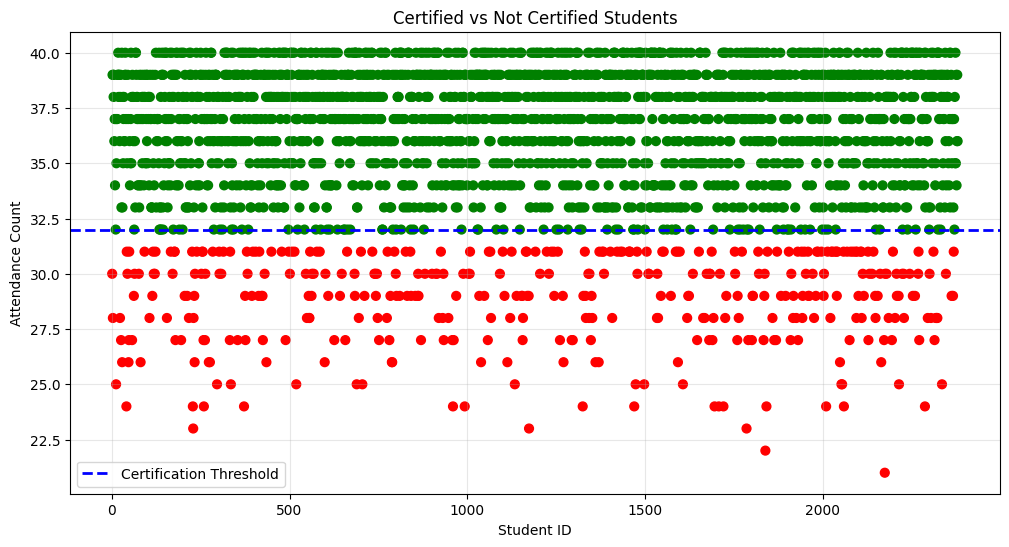


Files Saved Successfully!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
num_sessions = 40
attendance_records = {}
# Read all 40 files
for day in range(1, num_sessions + 1):
    file_name = f"Day{day}.xlsx"
    df = pd.read_excel(file_name)
    name_col = "Name (original name)"
    duration_col = "Duration (minutes).1"
    for _, row in df.iterrows():
        student = str(row[name_col]).strip()
        duration = row[duration_col]
        attendance = 1 if duration >= 30 else 0
        if student not in attendance_records:
            attendance_records[student] = [0] * num_sessions
        attendance_records[student][day - 1] = attendance
# Create DataFrame
attendance_df = pd.DataFrame.from_dict(
    attendance_records,
    orient="index"
)
attendance_df.reset_index(inplace=True)
attendance_df.rename(
    columns={"index": "Student_Name"},
    inplace=True
)
attendance_df.insert(
    0,
    "Student_ID",
    range(1, len(attendance_df) + 1)
)
# Rename session columns
for i in range(1, 41):
    attendance_df.rename(
        columns={i - 1: f"Session_{i}"},
        inplace=True
    )
session_columns = [
    f"Session_{i}"
    for i in range(1, 41)
]
# Attendance Calculation
attendance_df["Total_Attendance"] = (
    attendance_df[session_columns]
    .sum(axis=1)
)

attendance_df["Attendance_Percentage"] = (
    attendance_df["Total_Attendance"]
    / 40
) * 100
# Certification
attendance_df["Certification_Status"] = (
    attendance_df["Attendance_Percentage"]
    .apply(
        lambda x:
        "Certified"
        if x >= 80
        else "Not Certified"
    )
)
print("\nCertification Count:")
print(
    attendance_df["Certification_Status"]
    .value_counts()
)
# Scatter Plot
plt.figure(figsize=(12,6))
colors = attendance_df[
    "Certification_Status"
].map({
    "Certified": "green",
    "Not Certified": "red"
})
plt.scatter(
    attendance_df["Student_ID"],
    attendance_df["Total_Attendance"],
    c=colors,
    s=40
)
plt.axhline(
    y=32,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Certification Threshold"
)
plt.xlabel("Student ID")
plt.ylabel("Attendance Count")
plt.title("Certified vs Not Certified Students")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# Save Outputs
attendance_df.to_csv(
    "attendance_40_sessions.csv",
    index=False
)
attendance_df[
    attendance_df["Certification_Status"]
    == "Certified"
].to_csv(
    "certified_students.csv",
    index=False
)
attendance_df[
    attendance_df["Certification_Status"]
    == "Not Certified"
].to_csv(
    "not_certified_students.csv",
    index=False
)
print("\nFiles Saved Successfully!")